In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Input, Embedding , BatchNormalization , LSTM , Dropout , LayerNormalization
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler
from sklearn.metrics import r2_score

In [269]:
df = pd.read_csv(r"/content/Google_Stock_Train (2010-2022).csv")
df.drop(columns=['Adj Close' , 'Date'] , inplace = True)

df['return'] = df['Close'].pct_change()
df = df.dropna()
df.reset_index(inplace = True , drop=True)
df = np.array(df)
df

array([[ 1.56951950e+01,  1.57117120e+01,  1.55540540e+01,
         1.56153650e+01,  1.20067812e+08, -4.40366544e-03],
       [ 1.56621620e+01,  1.56621620e+01,  1.51741740e+01,
         1.52217220e+01,  1.58988852e+08, -2.52086967e-02],
       [ 1.52502500e+01,  1.52652650e+01,  1.48310810e+01,
         1.48673670e+01,  2.56315428e+08, -2.32795606e-02],
       ...,
       [ 8.69800030e+01,  8.80400010e+01,  8.59400020e+01,
         8.60199970e+01,  1.95232000e+07, -1.56768740e-02],
       [ 8.66200030e+01,  8.88499980e+01,  8.66100010e+01,
         8.84499970e+01,  2.33335000e+07,  2.82492453e-02],
       [ 8.69800030e+01,  8.83000030e+01,  8.65700000e+01,
         8.82300030e+01,  2.39863000e+07, -2.48721320e-03]])

In [354]:
day_size = 10

x_train = []
y_train = []
prev_prices = []

for i in range(0 , len(df)-day_size):
    days_arr = []
    for day in range(0 , day_size):
        days_arr.append(df[day+(i)])
    x_train.append(days_arr)
    y_train.append(df[i+day_size , 5])
    prev_prices.append(df[i+day_size-1 , 3])

In [355]:
x_train = np.array(x_train)
y_train = np.array(y_train)

In [356]:
nsamples, timesteps, nfeatures = x_train.shape

x_scaler = RobustScaler()
y_scaler = RobustScaler()

x_train_scaled_2d  = x_scaler.fit_transform(x_train.reshape(-1, nfeatures))

x_train_scaled = x_train_scaled_2d.reshape(nsamples, timesteps, nfeatures)
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1 , 1))

In [357]:
x_train_scaled.shape

(3261, 10, 6)

In [358]:
model = Sequential()

model.add(Input(shape=(day_size , x_train_scaled.shape[2], )))

model.add(LSTM(10 ,dropout=0.1, recurrent_dropout=0.1, return_sequences=False))
model.add(LayerNormalization())
# model.add(Dropout(0.1))

model.add(Dense(10 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.05)))
model.add(BatchNormalization())
# model.add(Dropout(0.1))

model.add(Dense(1 , activation = 'linear'))

model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_53 (LSTM)                  │ (None, 10)             │           680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_12          │ (None, 10)             │            20 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 861 (3.36 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 20 (80.00 B)

In [359]:
import tensorflow as tf
from tensorflow.keras import backend as K

# def r2_score(y_true, y_pred):
#     ss_res =  K.sum(K.square(y_true - y_pred))
#     ss_tot =  K.sum(K.square(y_true - K.mean(y_true)))
#     return 1 - ss_res/(ss_tot + K.epsilon())


In [360]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),         # Adam optimizer is a good default choice
    loss='mae',# MSE loss is standard for regression tasks
    metrics=['mean_absolute_error' ]  # MAE is a good additional metric to monitor
)

In [361]:
history = model.fit(x_train_scaled , y_train_scaled , batch_size = 50 , epochs = 10 , )

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 1.5401 - mean_absolute_error: 1.0900
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.1843 - mean_absolute_error: 0.7979
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.0922 - mean_absolute_error: 0.7708
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 1.0091 - mean_absolute_error: 0.7434
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.9434 - mean_absolute_error: 0.7241
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.9198 - mean_absolute_error: 0.7384
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.8745 - mean_absolute_error: 0.7233
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.8428 - mean_absolute_error: 0.7164
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.8102 - mean_absolute_error: 0.7041
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.8157 - mean_absolute_error: 0.7261


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


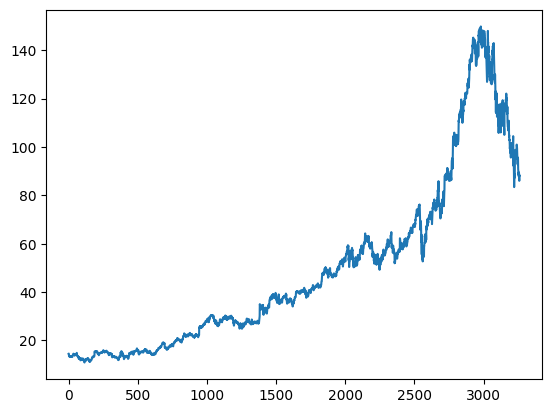

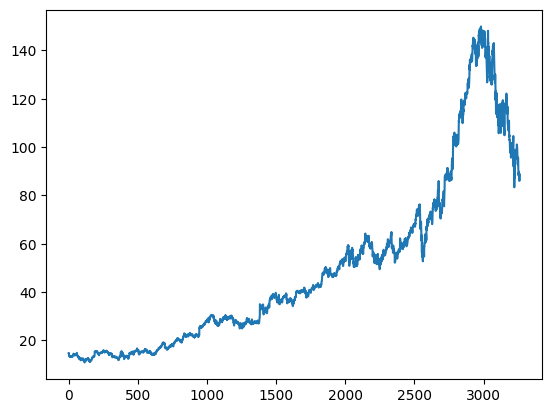

In [362]:
predicted_return = model.predict(x_train_scaled)

predicted_return = y_scaler.inverse_transform(predicted_return)

predicted_price = prev_prices * (1 + predicted_return.flatten())

# print(y_pred)

plt.plot(df[day_size: , 3])
plt.show()
plt.plot(predicted_price)


In [363]:

y_true = df[day_size:, 3].astype(np.float64)
y_pred = predicted_price.astype(np.float64)

r2 = r2_score(y_true, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9990056714930642


In [332]:
google_df = pd.read_csv(r"/content/GOOG_2004-08-19_2025-08-20.csv")
google_df = google_df[~google_df['date'].isna()]
google_df = google_df[(google_df['date'].str.startswith('2023')) |
          (google_df['date'].str.startswith('2024')) |
          (google_df['date'].str.startswith('2025'))]

google_df.drop(columns=['adj_close' , 'date'] , inplace = True)
google_df.reset_index(inplace = True , drop=True)

cols = google_df.columns.values
for col in cols:
    google_df[col] = google_df[col].astype(np.float64)


google_df['return'] = google_df['close'].pct_change()
google_df = google_df.dropna()
google_df.reset_index(inplace = True , drop=True)

google_df = np.array(google_df)
# google_df

In [364]:
# day_size = 20

x_test = []
y_test = []
test_prev_prices = []

for i in range(0 , len(google_df)-day_size):
    days_arr = []
    for day in range(0 , day_size):
        days_arr.append(google_df[day+(i)])
    x_test.append(days_arr)
    y_test.append(google_df[i+day_size , 5])
    test_prev_prices.append(google_df[i+day_size-1 , 3])

In [365]:
x_test = np.array(x_test)
y_test = np.array(y_test)

In [366]:
x_test.shape

(648, 10, 6)

In [367]:
nsamples, timesteps, nfeatures = x_test.shape

# x_scaler = MinMaxScaler(feature_range=(0,1))
# y_scaler = MinMaxScaler(feature_range=(0,1))

x_test_scaled_2d  = x_scaler.transform(x_test.reshape(-1, nfeatures))

x_test_scaled = x_test_scaled_2d.reshape(nsamples, timesteps, nfeatures)
y_test_scaled = y_scaler.transform(y_test.reshape(-1 , 1))

In [341]:
y_test_scaled.shape

(648, 1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


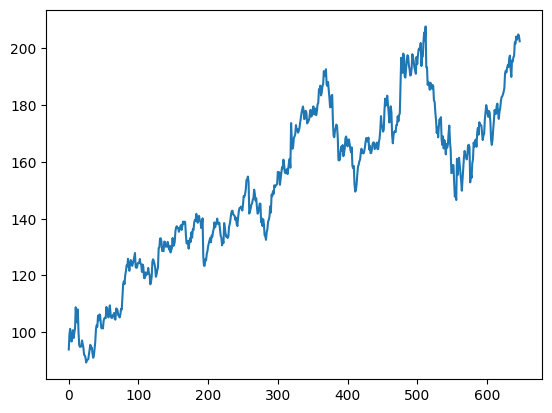

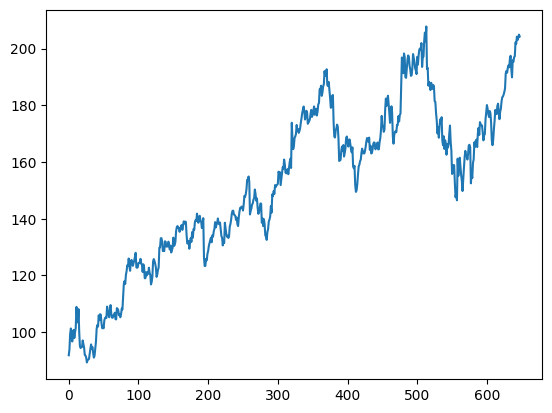

In [368]:
predicted_return = model.predict(x_test_scaled)

predicted_return = y_scaler.inverse_transform(predicted_return)

predicted_price = test_prev_prices * (1 + predicted_return.flatten())

# print(y_pred)

plt.plot(google_df[day_size: , 3])
plt.show()
plt.plot(predicted_price)

In [369]:

y_true = google_df[day_size:, 3].astype(np.float64)
y_pred = predicted_price.astype(np.float64)

r2 = r2_score(y_true, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9899928462107322
